# Project Final Report

### Due: Midnight on April 27 (2-hour grace period) — 50 points  

### No late submissions will be accepted.


## Overview

Your final submission consists of **three components**:

---

### 1. Final Report Notebook [40 pts]

Complete all sections of this notebook to document your final decisions, results, and broader context.

- **Part A**: Select the single best model from your Milestone 2 experiments. Now that you’ve finalized your model, revisit your decisions from Milestones 1 and 2. Are there any steps you would change—such as cleaning, feature engineering, or model evaluation—given what you now know?

- **Part B**: Write a technical report following standard conventions, for example:
  - [CMU guide to structure](https://www.stat.cmu.edu/~brian/701/notes/paper-structure.pdf)
  - [Data science report example](https://www.projectpro.io/article/data-science-project-report/620)
  - The Checklist given in this week's Blackboard Lesson (essentially the same as in HOML).
    
  Your audience here is technically literate but unfamiliar with your work—like your manager or other data scientists. Be clear, precise, and include both code (for illustration), charts/plots/illustrations, and explanation of what you discovered and your reasoning process. 

The idea here is that Part A would be a repository of the most important code, for further work to come, and Part B is
the technical report which summarizes your project for the data science group at your company. Do NOT assume that readers of Part B are intimately familiar with Part A; provide code for illustration as needed, but not to run.

Submit this notebook as a group via your team leader’s Gradescope account.

---

### 2. PowerPoint Presentation [10 pts]

Create a 10–15 minute presentation designed for a general audience (e.g., sales or marketing team).

- Prepare 8–12 slides, following the general outline of the sections of Part B. 
- Focus on storytelling, visuals (plots and illustrations), and clear, simplified language. No code!
- Use any presentation tool you like, but upload a PDF version.
- List all team members on the first slide.

Submit as a group via your team leader’s Gradescope account.

---

### 3. Individual Assessment

Each team member must complete the Individual Assessment Form (same as in Milestone 1), sign it, and upload it via their own Gradescope account.

---

## Submission Checklist

-  Final Report Notebook — Team leader submission
-  PDF Slides — Team leader submission
-  Individual Assessment Form — Each member submits their own


## Part A: Final Model and Design Reassessment [10 pts]

In this part, you will finalize your best-performing model and revisit earlier decisions to determine if any should be revised in light of your complete modeling workflow. You’ll also consolidate and present the key code used to run your model on the preprocessed dataset, with thoughtful documentation of your reasoning.

**Requirements:**

- Reconsider **at least one decision from Milestone 1** (e.g., preprocessing, feature engineering, or encoding). Explain whether you would keep or revise that decision now that you know which model performs best. Justify your reasoning.
  
- Reconsider **at least one decision from Milestone 2** (e.g., model evaluation, cross-validation strategy, or feature selection). Again, explain whether you would keep or revise your original decision, and why.

- Below, include all code necessary to **run your final model** on the processed dataset. This section should be a clean, readable summary of the most important steps from Milestones 1 and 2, adapted as needed to fit your final model choice and your reconsiderations as just described. 

- Use Markdown cells and inline comments to explain the structure of the code clearly but concisely. The goal is to make your reasoning and process easy to follow for instructors and reviewers.

> Remember: You are not required to change your earlier choices, but you *are* required to reflect on them and justify your final decisions.


In [1]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# Scikit-learn imputation & pipelinefrom sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

# from sklearn.exceptions import ConvergenceWarning
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)

## Helper Functions

In [2]:
def show_null_counts_features(df):
    # Count the nulls and calculate the %
    count_nulls = df.isnull().sum()
    df_nulls = (df.isnull().mean() * 100).round(2)

    # Determine if the column is numeric or non-numeric
    feature_types = df.dtypes.apply(lambda x: 'Numeric' if np.issubdtype(x, np.number) else 'Categorical')

    # Filter out the columns with missing values and sort them in descending order
    missing_data = pd.DataFrame({
        'Feature': count_nulls[count_nulls > 0].index,
        '# Null Values': count_nulls[count_nulls > 0].values,
        'Null %': df_nulls[df_nulls > 0].values,
        'Type': feature_types[count_nulls > 0].values
    }).sort_values(by='Null %', ascending=False)

    print(f'The dataset contains {len(df)} samples.\n')

    if (len(missing_data) == 0):
        print("There are no null values in the dataset!")
    else:
        # Print null value stats
        print('Feature Name    # Nulls      Null %    Type')
        print('------------    -------      ------    ----')
        for index, row in missing_data.iterrows():
            print(f"{row['Feature']:<15} {row['# Null Values']:<12} {row['Null %']:.2f}%   {row['Type']}")

def row_missingness_summary(df: pd.DataFrame) -> pd.DataFrame:
    # Count how many columns are missing in each row
    missing_counts = df.isnull().sum(axis=1)
    # Calculate the fraction of columns that are missing in each row
    total_cols = df.shape[1]
    missing_ratios = missing_counts / total_cols

    # Create a summary DataFrame
    summary_df = pd.DataFrame({
        'missing_count': missing_counts,
        'missing_ratio': missing_ratios
    })
    summary_df.sort_values(by='missing_ratio', ascending=False, inplace=True)

    return summary_df

def drop_rows_with_missingness(df: pd.DataFrame, threshold: float = 0.5) -> pd.DataFrame:
    # Compute the fraction of missing values for each row
    row_missing_ratios = df.isnull().mean(axis=1)
    # Keep only rows with missing ratio <= threshold
    df_filtered = df[row_missing_ratios <= threshold].copy()

    return df_filtered


def remove_outliers_iqr(
    df: pd.DataFrame,
    column: str,
    multiplier: float = 1.5,
    clamp_lower_to_zero: bool = False
) -> tuple[pd.DataFrame, float, float, float, float]:
    """
    Remove outliers based on the IQR rule.

    Returns:
      df_cleaned    – DataFrame filtered to values within [lower, upper]
      lower         – theoretical lower cutoff (clamped if requested)
      upper         – theoretical upper cutoff
      actual_min    – min value in the cleaned df
      actual_max    – max value in the cleaned df
    """
    col = pd.to_numeric(df[column], errors='coerce').dropna()

    # Compute quantiles
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1

    # Theoretical bounds
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR

    # Optional clamp
    if clamp_lower_to_zero:
        lower = max(0, lower)

    # Filter
    mask = col.between(lower, upper)
    df_cleaned = df.loc[mask.index[mask]].copy()

    # Observed bounds
    actual_min = df_cleaned[column].min()
    actual_max = df_cleaned[column].max()

    # Debug print (optional)
    print(f"Q1={Q1:.3f}, Q3={Q3:.3f}, IQR={IQR:.3f}")
    print(f"cutoffs → lower={lower:.3f}, upper={upper:.3f}")
    print(f"cleaned data range → min={actual_min:.3f}, max={actual_max:.3f}")

    return df_cleaned, lower, upper, actual_min, actual_max

# turn the one value columns into 0/1 columns
def fill_one_hot_columns(df, inplace: bool = False) -> pd.DataFrame:
    target_df = df if inplace else df.copy()
    for col in target_df.columns:
        non_na = target_df[col].dropna()
        if not non_na.empty and non_na.eq(1).all():
            target_df[col] = target_df[col].fillna(0)
    if not inplace:
        return target_df
    
# Forward Feature Selection Function Definition
def directional_feature_selection(model, direction, x, y):
  '''
  This function runs a directional feature selection.

  Parameters:
  -----------
    model (sklearn model): the model to be tested on.
    direction (str): either 'forward' or 'backward'
    x (np.DataFrame or np.array): The features
    y (np.DataFrame or np.array): The target

  Returns:
  --------
    selected (np.array): The selected features' names.
  '''
  selector = SequentialFeatureSelector(model, n_features_to_select='auto', direction=direction)
  selector.fit(x, y)
  selected = selector.get_feature_names_out()
  return selected

# Log Feature Function
def log_transform_feature(df, feature):
  '''
  This log transforms a feature to create a new feature in a DataFrame.

  Parameters:
  -----------
    df (np.DataFrame): The features.
    feature (str): The name of the feature to be transformed.

  Returns:
  --------
    df (np.DataFrame): The features.
  '''
  if feature not in df.columns:
    raise ValueError('Error: Features (bed and bath) not found.')
  else:
    new_name = 'log_' + feature
    df[new_name] = np.log1p(df[feature])
    df[new_name] = df[new_name].fillna(1)
    df[new_name] = df[new_name].replace([np.inf, -np.inf], 1)
    return df

# BedBath Calc Function
def calc_bedbath_feature(df, bedname, bathname):
  '''
  This calculates the number of beds over the number of baths to create a new feature in the DataFrame.

  Parameters:
  -----------
    df (np.DataFrame): The features.
    bedname (str): The name of one the features to be transformed.
    bathname (str): The name of one the features to be transformed.

  Returns:
  --------
    df (np.DataFrame): The features.
  '''
  if bedname not in df.columns and bathname not in df.columns:
    raise ValueError('Error: Features (bed and bath) not found.')
  else:
    new_name = 'calc_bedbath'
    df[new_name] = df[bedname] / df[bathname]
    df[new_name] = df[new_name].fillna(1)
    df[new_name] = df[new_name].replace([np.inf, -np.inf], 1)
    return df

# Polynomial Feature Function - Product
def calc_product_feature(df, feature1, feature2):
  '''
  This calculates the product of two to create a new feature in a DataFrame.

  Parameters:
  -----------
    df (np.DataFrame): The features.
    feature1 (str): The name of one the features to be transformed.
    feature2 (str): The name of one the features to be transformed.

  Returns:
  --------
    df (np.DataFrame): The features.
  '''
  if feature1 not in df.columns and feature2 not in df.columns:
    raise ValueError('Error: Features (bed and bath) not found.')
  else:
    new_name = 'prod_' + feature1 + '_' + feature2
    df[new_name] = df[feature1] * df[feature2]
    df[new_name] = df[new_name].fillna(1)
    return df
  
# to attempt to disable lasso warning
def safe_cross_val_score(model, X, y, **kwargs):
    import warnings
    from sklearn.exceptions import ConvergenceWarning
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        return cross_val_score(model, X, y, **kwargs)

## Initial Data Processing

We made a few changes:

1. Adjustment to the cutoff point for columns with null values from ".9 to .8"
2. Dropping the `heatingorsystemtypeID` and `airconditioningtypeid` based on their relatively weak F-Statistic
3. Adjustment to the % of blank column values that would drop a row from the dataset from `.5` to `.25`

The biggest change is fixing a bug we found in our milestone 1 code. The code used to drop target columns outside the IQR was not working, which seriously hurt model performance. After fixing that code the dataset is about 20% smaller and the `RSME_STD` is 10x smaller than it previously was, suggesting that it was this bug that was most seriously impacting model performance

In [ ]:
# download dataset
url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

# First round of column drops 
single_value_features = [col for col in df.columns if df[col].nunique() == 1]

#make a copy of the DataFrame
df_clean = df.copy()

#drop the columns with only 1 unique value identified by Nowrin
#df_clean = df_clean.drop(columns=single_value_features).copy() #drop the columns with only 1 unique value identified by Nowrin

#drop unique identifier
df_clean = df_clean.drop(columns=['parcelid']) #drop unique identifier

# drop redundant columns (we'll get the rest when we drop features with too many nulls)
other_drops = ['propertycountylandusecode', #sparse/categorical
               'propertylandusetypeid', #sparse/categorical
               'propertyzoningdesc', #string
               'rawcensustractandblock', #possibly redundant with lat/long
               'regionidneighborhood', #redundant with other location data
               'censustractandblock', #possibly redundant with lat/long
               'calculatedbathnbr', # we've got beds and bathrooms and this will cause a problem with the imputed
               'assessmentyear', # year of assessment, not useful for prediction
               'fullbathcnt', # we've got beds and bathrooms and this will cause a problem with the imputed
               'regionidzip',
               'regionidcity', #redundant with other location data
               'latitude',
               'longitude', #redundant with other location data
               'heatingorsystemtypeid', #sparse/categorical
               'airconditioningtypeid', #sparse/categorical
               ]

df_clean = df_clean.drop(columns=other_drops)

# drop null columns
max_nulls = len(df_clean) * .8 # roll down to 80% from 90%
cnt_nulls = df_clean.isnull().sum()
null_high = df_clean.columns[df_clean.isnull().sum() > max_nulls]
df_clean = df_clean.drop(columns=null_high)

# drop rows with missing target and rows with more than 50% missing columns values
df_clean = df_clean.dropna(subset=['taxvaluedollarcnt']) #drop rows with missing target
df_clean = drop_rows_with_missingness(df_clean, threshold=0.25) #drop rows where more than 25% of the columns were missing values

# removing outliers
df_clean, lower, upper, obs_min, obs_max = remove_outliers_iqr(df_clean, 'taxvaluedollarcnt', multiplier=1.5, clamp_lower_to_zero=True)
df_clean['taxvaluedollarcnt'].describe()
print(f"final dataframe length: {len(df_clean['taxvaluedollarcnt'])}")

# fill one-hot columns (if needed)
#fill_one_hot_columns(df_clean, inplace=True)

File already exists. Skipping download.
Q1=201392.000, Q3=575487.250, IQR=374095.250
cutoffs → lower=0.000, upper=1136630.125
cleaned data range → min=1000.000, max=1136598.000
final dataframe length: 62814


## Imputation Pipeline
- Key Revision: Swapped the iterative imputer out for a simple imputer and revised the pipeline to keep the columns in their original order, rather than the previous implementation that split the pipeline into two datasets based on their imputation type. I experimented with the KNN imputer but it did not meaningfully improve model performance. 

In [4]:
# 1) Pull out the target so it isn’t touched by imputation
df_impute = df_clean.drop(columns=["taxvaluedollarcnt"])
target = df_clean["taxvaluedollarcnt"]

# 2) Define which columns are “categorical” (everything else numeric)
categorical_features = [
    "buildingqualitytypeid",
    "fips",
    "regionidcounty",
    "unitcnt",
    "calculatedfinishedsquarefeet",
    "yearbuilt"
]
numeric_features = [c for c in df_impute.columns if c not in categorical_features]

# 3) Build pipelines: median for numeric, most_frequent for categorical
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_features),
    ("cat", cat_pipeline, categorical_features),
])

# 4) Fit & transform
arr = preprocessor.fit_transform(df_impute)

# 5) Rebuild DataFrame in original order
filled = pd.DataFrame(
    arr,
    columns=numeric_features + categorical_features,
    index=df_impute.index
)[df_impute.columns]

# 6) Put the target back on
df_final = filled.assign(taxvaluedollarcnt=target)

df_final.head()


,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,garagecarcnt,garagetotalsqft,lotsizesquarefeet,poolcnt,regionidcounty,roomcnt,unitcnt,yearbuilt,numberofstories,taxvaluedollarcnt
0,3.5,4.0,8.0,3100.0,3100.0,6059.0,2.0,633.0,4506.0,1.0,1286.0,0.0,1.0,1998.0,1.0,1023282.0
1,1.0,2.0,8.0,1465.0,1465.0,6111.0,1.0,0.0,12647.0,1.0,2061.0,5.0,1.0,1967.0,1.0,464000.0
2,2.0,3.0,8.0,1243.0,1243.0,6059.0,2.0,440.0,8432.0,1.0,1286.0,6.0,1.0,1962.0,1.0,564778.0
3,3.0,4.0,8.0,2376.0,2376.0,6037.0,2.0,443.5,13038.0,1.0,3101.0,0.0,1.0,1970.0,1.0,145143.0
4,3.0,3.0,8.0,1312.0,1312.0,6037.0,2.0,443.5,278581.0,1.0,3101.0,0.0,1.0,1964.0,1.0,119407.0


## Final Processing

No changes here - I again round down the the columns that only use int values to match the dataset

In [5]:
int_columns = ['bathroomcnt', 'bedroomcnt', 'garagecarcnt', 'roomcnt', 'unitcnt'] # add any categorical column value here that needs to get rounded to match the original data 

# Round and cast each column back to integer
for col in int_columns:
    df_final[col] = df_final[col].round().astype(int)

# Define your categorical features
categorical_features = [
    'fips', 'regionidcounty'
]

# Instantiate the OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical features
encoded_cats = encoder.fit_transform(df_final[categorical_features])

# Convert the encoded array back to a DataFrame
encoded_cat_df = pd.DataFrame(
    encoded_cats, 
    columns=encoder.get_feature_names_out(categorical_features), 
    index=df_final.index
)

# Identify the numeric features (everything that is not categorical)
numeric_features = [col for col in df_final.columns if col not in categorical_features]
df_numeric = df_final[numeric_features]

# Combine the numeric features with the encoded categorical features
df_encoded = pd.concat([df_numeric, encoded_cat_df], axis=1)

# x_y spli
x = df_encoded.drop(columns=['taxvaluedollarcnt'])
y = df_encoded['taxvaluedollarcnt']

# First making a copy of the df
x_eng = x.copy()

# Log of sqft
x_eng = log_transform_feature(x_eng, 'garagetotalsqft')
x_eng = log_transform_feature(x_eng, 'lotsizesquarefeet')
x_eng = log_transform_feature(x_eng, 'calculatedfinishedsquarefeet')

# # Bedbath feature
x_eng = calc_bedbath_feature(x_eng, 'bathroomcnt', 'bedroomcnt')

# # Product feature
x_eng = calc_product_feature(x_eng, 'bathroomcnt', 'bedroomcnt')
#x_eng = calc_product_feature(x_eng, 'fireplacecnt', 'garagecarcnt')

x_eng = x_eng.reset_index(drop=True)
y = y.reset_index(drop=True)
x_eng['taxvaluedollarcnt'] = y

print(x_eng['taxvaluedollarcnt'].isna().sum())
x_eng.to_csv('milestone_1_zillow.csv', index=False) #off ramp 1 - revamped dataset from milestone 1

0


## Milestone 2 Work

In [6]:
# Add as many code cells as you need
df = pd.read_csv('milestone_1_zillow.csv')

# train_test_split set up 
X = df.drop(columns=['taxvaluedollarcnt'])
y = df['taxvaluedollarcnt']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# define the models to evaluate
models = {'Gradient Boosting': GradientBoostingRegressor()}

# Set up cross-validation: using 5-fold CV repeated 5 times.
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

# Define an RMSE scorer (note: 'neg_root_mean_squared_error' will return negative RMSE values)
scorer = make_scorer(mean_squared_error, squared=False)

# Store results
results = []

for name, model in models.items():
    # Using n_jobs=-1 to parallelize CV across all cores
    scores = safe_cross_val_score(model, X_train, y_train, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1)
    # Convert negative RMSE values to positive
    rmse_scores = -scores
    results.append({
        'Model': name,
        'Mean RMSE': np.mean(rmse_scores),
        'Std RMSE': np.std(rmse_scores)
    })

# Save results to a DataFrame
results_df = pd.DataFrame(results)
print(results_df)

(50251, 24) (12563, 24) (50251,) (12563,)
               Model      Mean RMSE     Std RMSE
0  Gradient Boosting  196103.291529  1349.205623


## Milestone 2 Helper Functions

In [7]:
# Log Feature Function
def log_transform_feature(df, feature):
  '''
  This log transforms a feature to create a new feature in a DataFrame.

  Parameters:
  -----------
    df (np.DataFrame): The features.
    feature (str): The name of the feature to be transformed.

  Returns:
  --------
    df (np.DataFrame): The features.
  '''
  df = df.copy()
  if feature not in df.columns:
    raise ValueError('Error: Features (bed and bath) not found.')
  else:
    new_name = 'log_' + feature
    df[new_name] = np.log1p(df[feature])
    df[new_name] = df[new_name].fillna(1)
    df[new_name] = df[new_name].replace([np.inf, -np.inf], 1)
    return df.copy()

# BedBath Calc Function
def calc_bedbath_feature(df, bedname, bathname):
  '''
  This calculates the number of beds over the number of baths to create a new feature in the DataFrame.

  Parameters:
  -----------
    df (np.DataFrame): The features.
    bedname (str): The name of one the features to be transformed.
    bathname (str): The name of one the features to be transformed.

  Returns:
  --------
    df (np.DataFrame): The features.
  '''
  df = df.copy()
  if bedname not in df.columns and bathname not in df.columns:
    raise ValueError('Error: Features (bed and bath) not found.')
  else:
    new_name = 'calc_bedbath'
    df[new_name] = df[bedname] / df[bathname]
    df[new_name] = df[new_name].fillna(1)
    df[new_name] = df[new_name].replace([np.inf, -np.inf], 1)
    return df

# Polynomial Feature Function - Product
def calc_product_feature(df, feature1, feature2):
  '''
  This calculates the product of two to create a new feature in a DataFrame.

  Parameters:
  -----------
    df (np.DataFrame): The features.
    feature1 (str): The name of one the features to be transformed.
    feature2 (str): The name of one the features to be transformed.

  Returns:
  --------
    df (np.DataFrame): The features.
  '''
  df = df.copy()
  if feature1 not in df.columns and feature2 not in df.columns:
    raise ValueError('Error: Features (bed and bath) not found.')
  else:
    new_name = 'prod_' + feature1 + '_' + feature2
    df[new_name] = df[feature1] * df[feature2]
    df[new_name] = df[new_name].fillna(1)
    return df
  
# Calculate Age instead of year built
def calc_age_feature(df, yearbuiltfeature):
  '''
  This calculates the Age from the yearbuilt in a DataFrame.

  Parameters:
  -----------
    df (np.DataFrame): The features.
    yearbuiltfeature (str): The name of the feature to be transformed.

  Returns:
  --------
    df (np.DataFrame): The features.
  '''
  df = df.copy()
  if yearbuiltfeature not in df.columns:
    raise ValueError('Error: Features (yearbuilt) not found.')
  new_name = 'age'
  df[new_name] = (2025 - df[yearbuiltfeature])
  return df

from joblib import Parallel, delayed

def forward_feature_selection(X_train, y_train, model, 
                              scoring='neg_mean_squared_error', 
                              cv_folds=5, 
                              tol=None,
                              max_features=None,
                              verbose=False):

    selected_features = []                         
    remaining_features = list(X_train.columns)     
    rmse_history = []                              
    prev_rmse = float('inf')                       

    best_subset = None                            
    best_rmse = float('inf')                       

    # Precompute the cross-validation splits to avoid recomputing them for each candidate
    cv = RepeatedKFold(n_splits=cv_folds, n_repeats=1, random_state=42)
    cv_splits = list(cv.split(X_train))
    
    # Utility function to evaluate candidate feature performance
    def evaluate_candidate(feature, current_features):
        trial_features = current_features + [feature]
        # Use n_jobs=1 here to avoid nested parallelism since we are parallelizing at the outer level
        mse_scores = cross_val_score(model, X_train[trial_features], y_train,
                                     scoring=scoring, cv=cv_splits, n_jobs=1)
        rmse_score = np.sqrt(-np.mean(mse_scores))
        return feature, rmse_score

    while remaining_features:
        # Evaluate candidate features in parallel using joblib.Parallel
        candidate_results = Parallel(n_jobs=-1)(
            delayed(evaluate_candidate)(feature, selected_features)
            for feature in remaining_features
        )
        # Build a dictionary of candidate features and their corresponding RMSE scores
        scores = {feature: rmse for feature, rmse in candidate_results}
        
        # Identify the best candidate based on RMSE
        best_feature = min(scores, key=scores.get)
        current_rmse = scores[best_feature]
        
        # Stop early if improvement is lower than the tolerance
        if tol is not None and (prev_rmse - current_rmse < tol):
            if verbose:
                print("Stopping early due to minimal improvement.")
            break

        selected_features.append(best_feature)
        rmse_history.append(current_rmse)
        remaining_features.remove(best_feature)
        prev_rmse = current_rmse

        if verbose:
            print(f"Step {len(selected_features)}: Added {best_feature} | RMSE: {current_rmse:.4f}")

        if current_rmse < best_rmse:
            best_rmse = current_rmse
            best_subset = selected_features.copy()

        if max_features is not None and len(selected_features) >= max_features:
            break

    # Plotting the progress of CV RMSE over added features
    if best_subset:
        best_index = selected_features.index(best_subset[-1])
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(rmse_history) + 1), rmse_history, marker='o')
        plt.plot([best_index + 1], [best_rmse], marker='x', color='red')  # Highlight best RMSE
        plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation=60, ha='right', fontsize=6)
        plt.title('Forward Feature Selection - CV RMSE')
        plt.xlabel('Features Added')
        plt.ylabel('CV Score (RMSE)')
        plt.grid()
        plt.tight_layout()
        plt.show()

    return best_subset, best_rmse, rmse_history

def run_model(model, X_train, y_train, X_test, y_test, n_repeats=10, n_jobs=-1, **model_params):

    # Instantiate the model if a class is provided, so for example can use either BaggingRegressor or BaggingRegressor() as argument. 
    if isinstance(model, type):
        model = model(**model_params)

    neg_mse_scores = cross_val_score(model, X_train, y_train,scoring = 'neg_mean_squared_error',
                                     cv = RepeatedKFold(n_splits=5, n_repeats=n_repeats, random_state=42), n_jobs  = n_jobs)
    
    mean_cv_mse = -np.mean(neg_mse_scores)
    std_cv_mse  = np.std(neg_mse_scores)
    
    # Fit the model on the full training set
    model.fit(X_train, y_train)
    
    # Compute training MSE and testing MSE
    train_preds = model.predict(X_train)
    train_mse   = mean_squared_error(y_train, train_preds)
    test_preds  = model.predict(X_test)
    test_mse    = mean_squared_error(y_test, test_preds)
    
    return mean_cv_mse, std_cv_mse, train_mse, test_mse

def sweep_parameter(model,
                    Parameters,
                    param,
                    parameter_list,
                    X_train,        
                    y_train,          
                    X_test,           
                    y_test,           
                    verbose          = True,
                    show_rmse        = True,
                    n_iter_no_change = None,
                    delta            = 0.001,
                    n_jobs           = -1,
                    n_repeats        = 10):
    
    start = time.time()
    Parameters = Parameters.copy()  # Avoid modifying the original dictionary
    
    cv_mses, std_cvs, train_mses, test_mses = [], [], [], []
    no_improve_count = 0
    best_mse = float('inf')
    
    # Run over each value in parameter_list
    for p in tqdm(parameter_list, desc=f"Sweeping {param}"):
        Parameters[param] = p
        P_temp = Parameters.copy()
        # Remove MSE_found if present, just in case
        P_temp.pop('MSE_found', None)
        
        cv_mse, std_cv, train_mse, test_mse = run_model(
            model=model,
            X_train=X_train, y_train=y_train,
            X_test=X_test,   y_test=y_test,
            n_repeats=n_repeats,
            n_jobs=n_jobs,
            **P_temp
        )
        cv_mses.append(cv_mse)
        std_cvs.append(std_cv)
        train_mses.append(train_mse)
        test_mses.append(test_mse)
        
        # Early-stopping logic
        if cv_mse < best_mse - delta:
            best_mse = cv_mse
            no_improve_count = 0
        else:
            no_improve_count += 1
        
        if n_iter_no_change is not None and no_improve_count >= n_iter_no_change:
            print(f"Early stopping: No improvement after {n_iter_no_change} iterations.")
            break
    
    # Identify best parameter
    min_cv_mse = min(cv_mses)
    min_index = cv_mses.index(min_cv_mse)
    best_param = parameter_list[min_index]
    Parameters[param] = best_param
    Parameters['MSE_found'] = min_cv_mse
    
    if verbose:
        # Prepare for plotting
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
        
        # We only need as many parameter values as we actually computed
        partial_param_list = parameter_list[:len(cv_mses)]
        
        # Check if our parameter list is Boolean so we can label accordingly
        is_boolean = all(isinstance(val, bool) for val in partial_param_list)
        if is_boolean:
            # Convert booleans to integer indices for plotting
            x_vals = list(range(len(partial_param_list)))
            x_labels = [str(val) for val in partial_param_list]
        else:
            # Treat numeric or other types as-is
            x_vals = partial_param_list
            x_labels = partial_param_list
        
        error_name = 'RMSE' if show_rmse else 'MSE'
        
        # ----- First plot: (R)MSE -----
        ax1.set_title(f"{error_name} vs {param}")
        
        # Apply dollar formatting ONLY if we're showing RMSE
        if show_rmse:
            ax1.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
        
        # Plot lines
        ax1.plot(x_vals,
                 np.sqrt(cv_mses) if show_rmse else cv_mses,
                 marker='.', label=f"CV {error_name}", color='blue')
        ax1.plot(x_vals,
                 np.sqrt(train_mses) if show_rmse else train_mses,
                 marker='.', label=f"Train {error_name}", color='green')
        ax1.plot(x_vals,
                 np.sqrt(test_mses) if show_rmse else test_mses,
                 linestyle='--', label=f"Test {error_name}", color='orange')
        ax1.scatter([x_vals[min_index]],
                    [np.sqrt(min_cv_mse) if show_rmse else min_cv_mse],
                    marker='x', label=f"Best CV {error_name}", color='red')
        
        ax1.set_ylabel(error_name)
        ax1.legend()
        ax1.grid()
        
        # ----- Second plot: CV Std Dev -----
        ax2.set_title(f"CV Standard Deviation vs {param}")
        ax2.plot(x_vals, std_cvs, marker='.', label=f"CV {error_name} Std", color='blue')
        ax2.set_xlabel(param)
        ax2.set_ylabel("Standard Deviation")
        ax2.legend()
        ax2.grid(alpha=0.5)
        
        # If we are using boolean x-values, set custom ticks
        if is_boolean:
            ax2.set_xticks(x_vals)
            ax2.set_xticklabels(x_labels)
        
        plt.tight_layout()
        plt.show()
        
        end = time.time()
        print("Execution Time:", time.strftime("%H:%M:%S", time.gmtime(end - start)))
    
    return Parameters

## Feature Engineering

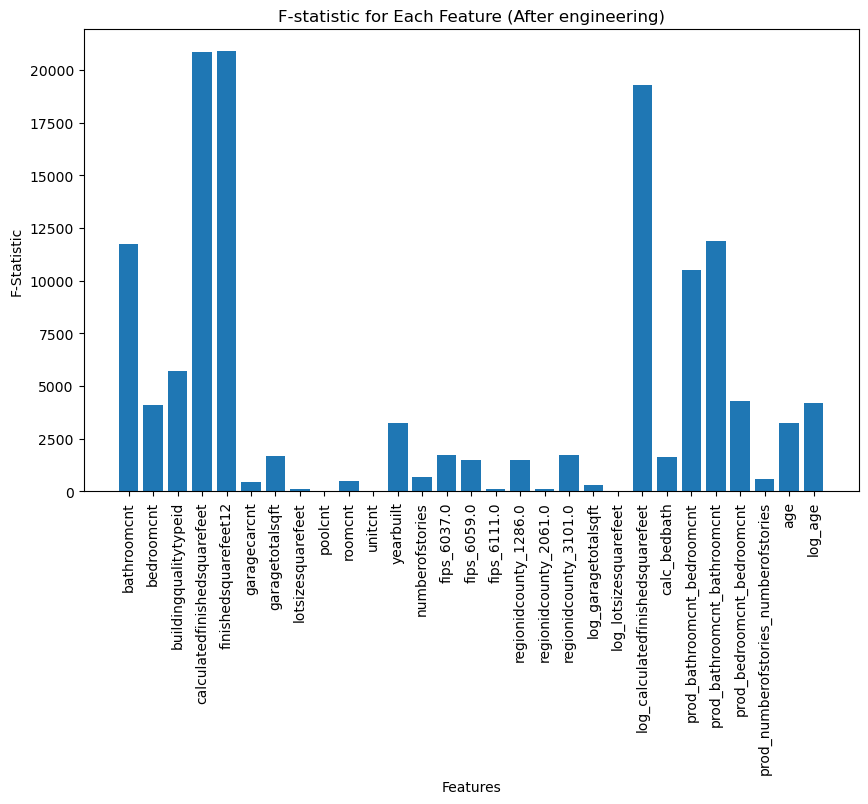

In [ ]:
# bath bath Poly
X_eng = calc_product_feature(X, 'bathroomcnt', 'bathroomcnt') # Improved fstat

# bed bed poly
X_eng = calc_product_feature(X_eng, 'bedroomcnt', 'bedroomcnt')

# floors floors poly
X_eng = calc_product_feature(X_eng, 'numberofstories', 'numberofstories') # Improved Fstat
# X_eng = calc_product_feature(X_eng, 'numberofstories', 'prod_numberofstories_numberofstories') --- worse fstat

# floors log
# X_eng = log_transform_feature(X_eng, 'numberofstories') --- worse fstat

# Age feature
X_eng = calc_age_feature(X_eng, 'yearbuilt') # similar fstat, but necessary for improvement seen in next line
X_eng = log_transform_feature(X_eng, 'age') # improved fstat
# X_eng = calc_product_feature(X_eng, 'age', 'age') --- worse fstat

# Fstatistics for Features
fstats, pvalues = f_regression(X_eng, y)
f_statistics = pd.DataFrame({'feature': X_eng.columns, 'f': fstats})

# Ploting the F's
plt.figure(figsize=(10, 6))
plt.bar(f_statistics['feature'], f_statistics['f'])
plt.title('F-statistic for Each Feature (After engineering)')
plt.xlabel('Features')
plt.ylabel('F-Statistic')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.show()

## scaling and final column selection

In [9]:
# Drop poorly engineered features
X_eng_dropped = X_eng.drop(columns=['log_calculatedfinishedsquarefeet', 'bathroomcnt', 'yearbuilt', 'numberofstories', 'calc_bedbath',
                                     'garagecarcnt', 'prod_bathroomcnt_bedroomcnt', 'bedroomcnt', 'log_garagetotalsqft', 'log_lotsizesquarefeet']) # Dropping redundant or poor fstat columns

# Standard Scaler
X_eng_train, X_eng_test, y_train, y_test = train_test_split(X_eng, y, test_size=0.2, random_state=random_state)
X_eng_train.shape, X_eng_test.shape, y_train.shape, y_test.shape

X_eng_dropped_train, X_eng_dropped_test, y_train, y_test = train_test_split(X_eng_dropped, y, test_size=0.2, random_state=random_state)
X_eng_dropped_train.shape, X_eng_dropped_test.shape, y_train.shape, y_test.shape

scaler2 = StandardScaler()
X_eng_train_scaled = scaler2.fit_transform(X_eng_train)
X_eng_test_scaled = scaler2.transform(X_eng_test)
X_eng_train_scaled = pd.DataFrame(X_eng_train_scaled, columns=X_eng_train.columns)
X_eng_test_scaled = pd.DataFrame(X_eng_test_scaled, columns=X_eng_test.columns)
X_eng_train_scaled.head()

scaler3 = StandardScaler()
X_eng_dropped_train_scaled = scaler3.fit_transform(X_eng_dropped_train)
X_eng_dropped_test_scaled = scaler3.transform(X_eng_dropped_test)
X_eng_dropped_train_scaled = pd.DataFrame(X_eng_dropped_train_scaled, columns=X_eng_dropped_train.columns)
X_eng_dropped_test_scaled = pd.DataFrame(X_eng_dropped_test_scaled, columns=X_eng_dropped_test.columns)
X_eng_dropped_train_scaled.head()

# Store results
results2 = []
results3 = []

# Running all features
for name, model in models.items():
    # Now using n_jobs=-1 to parallelize cross-validation internally
    scores = cross_val_score(model, X_eng_train_scaled, y_train, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1)
    rmse_scores = -scores  # convert to positive RMSE

    results2.append({
        'Model': name,
        'Mean RMSE': np.mean(rmse_scores),
        'Std RMSE': np.std(rmse_scores)
    })

# Results into a dataframe
results_df2 = pd.DataFrame(results2)

# Running w features dropped
for name, model in models.items():
    # Now using n_jobs=-1 to parallelize cross-validation internally
    scores = cross_val_score(model, X_eng_dropped_train_scaled, y_train, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1)
    rmse_scores = -scores  # convert to positive RMSE

    results3.append({
        'Model': name,
        'Mean RMSE': np.mean(rmse_scores),
        'Std RMSE': np.std(rmse_scores)
    })

# Results into a dataframe
results_df3 = pd.DataFrame(results3)

print(f"All features:\n{results_df2}\n\nFeatures Dropped:\n{results_df3}")

All features:
               Model      Mean RMSE     Std RMSE
0  Gradient Boosting  196102.837933  1349.108318

Features Dropped:
               Model      Mean RMSE     Std RMSE
0  Gradient Boosting  196224.378936  1312.345006


## Forward Selection


Running Forward Feature Selection for Gradient Boosting...



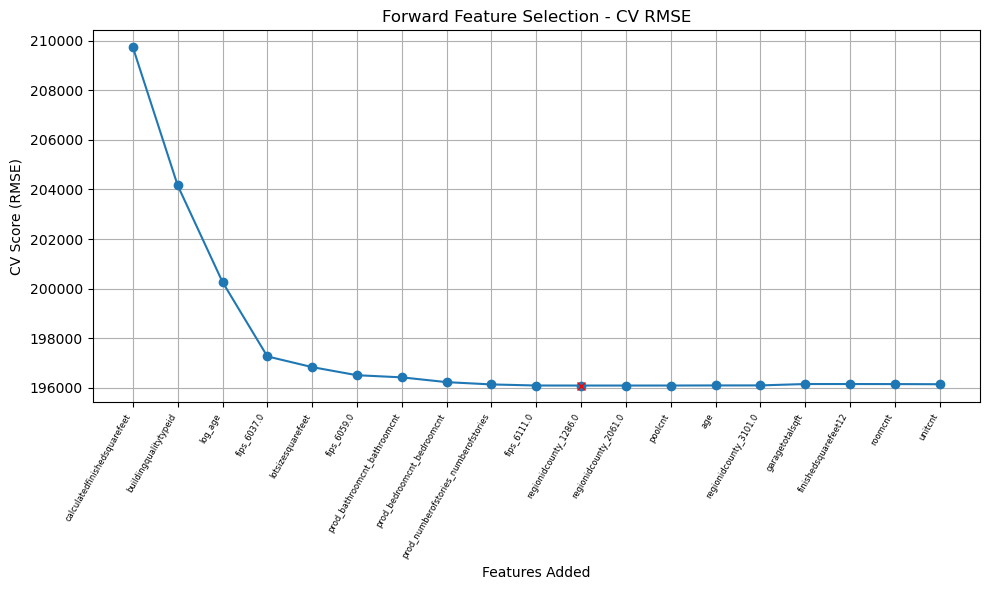

Best Subset of Features for Gradient Boosting: ['calculatedfinishedsquarefeet', 'buildingqualitytypeid', 'log_age', 'fips_6037.0', 'lotsizesquarefeet', 'fips_6059.0', 'prod_bathroomcnt_bathroomcnt', 'prod_bedroomcnt_bedroomcnt', 'prod_numberofstories_numberofstories', 'fips_6111.0', 'regionidcounty_1286.0']
Best CV RMSE: 196095.5262



In [10]:
models = {'Gradient Boosting': GradientBoostingRegressor()}

# Define thresholds 
tol_value = None    
max_features_value = None 

# Dictionary to store results
results_forward_selection = {}

for name, model in models.items():
    print(f"\nRunning Forward Feature Selection for {name}...\n")
    best_subset, best_rmse, rmse_history = forward_feature_selection(
        X_eng_dropped_train_scaled, y_train, model,  # Use cleaned feature set
        tol=tol_value,                
        max_features=max_features_value,  
        verbose=False
    )
    
    results_forward_selection[name] = {
        'best_subset': best_subset,
        'best_rmse': best_rmse
    }
    
    print(f"Best Subset of Features for {name}: {best_subset}")
    print(f"Best CV RMSE: {best_rmse:.4f}\n")

## Parameter Sweep

In [ ]:
## Parameter Sweep
best_gb_features = ['calculatedfinishedsquarefeet',
   'buildingqualitytypeid',
   'log_age',
   'fips_6037.0',
   'lotsizesquarefeet',
   'fips_6059.0',
   'prod_bathroomcnt_bathroomcnt',
   'prod_bedroomcnt_bedroomcnt',
   'prod_numberofstories_numberofstories',
   'regionidcounty_2061.0',
   'poolcnt']

# set dataframes according to "best_features_per_model"
X_train_reduced_gb = X_eng_dropped_train_scaled[best_gb_features]
X_test_reduced_gb = X_eng_dropped_test_scaled[best_gb_features]

default_gradient_boosting_regressor_params = {
    "loss": "squared_error",
    "learning_rate": 0.1,            
    "n_estimators": 100,              
    "subsample": 1.0,                 
    "criterion": "friedman_mse",
    "min_samples_split": 2,
    "min_samples_leaf": 1,            
    "min_weight_fraction_leaf": 0.0,  
    "max_depth": 3,
    "min_impurity_decrease": 0.0,
    "init": None,
    "random_state": None,
    "max_features": None,
    "verbose": 0,
    "max_leaf_nodes": None,
    "warm_start": False,
    "validation_fraction": 0.1,
    "n_iter_no_change": None,
    "tol": 1e-4,                  
    "ccp_alpha": 0.0}

# Set up parameter grid for Gradient Boosting Regressor sweeping loop
param_tests = {
    'loss': ['squared_error', 'absolute_error', 'huber', 'quantile'],
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3],
    'n_estimators': [50, 100, 150, 200],
    'subsample': [0.5, 0.75, 1.0],
    'criterion': ['friedman_mse', 'squared_error'],
    'min_samples_split': [2, 5, 10, 15, 20, 25],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10],
    'min_weight_fraction_leaf': [0.0, 0.01, 0.1],
    'max_depth': [3, 5, 7, 9],
    'min_impurity_decrease': [0.0, 0.01, 0.1],
    'max_features': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'max_leaf_nodes': [None, 5, 10, 15, 20],
    'warm_start': [False, True]
}

# Start with the default parameters
gb_params = default_gradient_boosting_regressor_params.copy()

# Loop over each parameter in param_tests and update gb_params accordingly.
for param, values in param_tests.items():
    print("\nSweeping parameter:", param)
    gb_params = sweep_parameter(
        model=GradientBoostingRegressor,
        Parameters=gb_params,
        param=param,
        parameter_list=values,
        X_train=X_train_reduced_gb,
        y_train=y_train,
        X_test=X_test_reduced_gb,
        y_test=y_test,
        verbose=False,
        show_rmse=True,
        n_iter_no_change=None,
        delta=0.001,
        n_jobs=-1,
        n_repeats=5
    )
    # Print the updated parameter dictionary and the best value for the current parameter.
    print("Updated parameters after sweeping", param, ":\n", gb_params)
    print("Best", param, ":", gb_params[param])
    print("Best (root) MSE:", np.sqrt(gb_params['MSE_found']))

# Optionally, print the final parameter dictionary:
print("\nFinal gradient boosting parameters:")
print(gb_params)


Sweeping parameter: loss


Sweeping loss: 100%|██████████| 4/4 [00:22<00:00,  5.52s/it]


Updated parameters after sweeping loss :
 {'loss': 'squared_error', 'learning_rate': 0.1, 'n_estimators': 100, 'subsample': 1.0, 'criterion': 'friedman_mse', 'min_samples_split': 2, 'min_samples_leaf': 1, 'min_weight_fraction_leaf': 0.0, 'max_depth': 3, 'min_impurity_decrease': 0.0, 'init': None, 'random_state': None, 'max_features': None, 'verbose': 0, 'max_leaf_nodes': None, 'warm_start': False, 'validation_fraction': 0.1, 'n_iter_no_change': None, 'tol': 0.0001, 'ccp_alpha': 0.0, 'MSE_found': np.float64(38507990510.246506)}
Best loss : squared_error
Best (root) MSE: 196234.52935262566

Sweeping parameter: learning_rate


Sweeping learning_rate: 100%|██████████| 5/5 [00:26<00:00,  5.28s/it]


Updated parameters after sweeping learning_rate :
 {'loss': 'squared_error', 'learning_rate': 0.3, 'n_estimators': 100, 'subsample': 1.0, 'criterion': 'friedman_mse', 'min_samples_split': 2, 'min_samples_leaf': 1, 'min_weight_fraction_leaf': 0.0, 'max_depth': 3, 'min_impurity_decrease': 0.0, 'init': None, 'random_state': None, 'max_features': None, 'verbose': 0, 'max_leaf_nodes': None, 'warm_start': False, 'validation_fraction': 0.1, 'n_iter_no_change': None, 'tol': 0.0001, 'ccp_alpha': 0.0, 'MSE_found': np.float64(37876422609.34434)}
Best learning_rate : 0.3
Best (root) MSE: 194618.65945829637

Sweeping parameter: n_estimators


...

Updated parameters after sweeping max_features :
 {'loss': 'squared_error', 'learning_rate': 0.3, 'n_estimators': 150, 'subsample': 1.0, 'criterion': 'squared_error', 'min_samples_split': 15, 'min_samples_leaf': 8, 'min_weight_fraction_leaf': 0.0, 'max_depth': 3, 'min_impurity_decrease': 0.1, 'init': None, 'random_state': None, 'max_features': 1.0, 'verbose': 0, 'max_leaf_nodes': None, 'warm_start': False, 'validation_fraction': 0.1, 'n_iter_no_change': None, 'tol': 0.0001, 'ccp_alpha': 0.0, 'MSE_found': np.float64(37736756058.81145)}
Best max_features : 1.0
Best (root) MSE: 194259.50699724184

Sweeping parameter: max_leaf_nodes


Sweeping max_leaf_nodes: 100%|██████████| 5/5 [00:38<00:00,  7.70s/it]


Updated parameters after sweeping max_leaf_nodes :
 {'loss': 'squared_error', 'learning_rate': 0.3, 'n_estimators': 150, 'subsample': 1.0, 'criterion': 'squared_error', 'min_samples_split': 15, 'min_samples_leaf': 8, 'min_weight_fraction_leaf': 0.0, 'max_depth': 3, 'min_impurity_decrease': 0.1, 'init': None, 'random_state': None, 'max_features': 1.0, 'verbose': 0, 'max_leaf_nodes': 15, 'warm_start': False, 'validation_fraction': 0.1, 'n_iter_no_change': None, 'tol': 0.0001, 'ccp_alpha': 0.0, 'MSE_found': np.float64(37736723741.16461)}
Best max_leaf_nodes : 15
Best (root) MSE: 194259.42381558896

Sweeping parameter: warm_start


Sweeping warm_start: 100%|██████████| 2/2 [00:15<00:00,  7.94s/it]

Updated parameters after sweeping warm_start :
 {'loss': 'squared_error', 'learning_rate': 0.3, 'n_estimators': 150, 'subsample': 1.0, 'criterion': 'squared_error', 'min_samples_split': 15, 'min_samples_leaf': 8, 'min_weight_fraction_leaf': 0.0, 'max_depth': 3, 'min_impurity_decrease': 0.1, 'init': None, 'random_state': None, 'max_features': 1.0, 'verbose': 0, 'max_leaf_nodes': 15, 'warm_start': False, 'validation_fraction': 0.1, 'n_iter_no_change': None, 'tol': 0.0001, 'ccp_alpha': 0.0, 'MSE_found': np.float64(37736713168.48239)}
Best warm_start : False
Best (root) MSE: 194259.396602796

Final gradient boosting parameters:
{'loss': 'squared_error', 'learning_rate': 0.3, 'n_estimators': 150, 'subsample': 1.0, 'criterion': 'squared_error', 'min_samples_split': 15, 'min_samples_leaf': 8, 'min_weight_fraction_leaf': 0.0, 'max_depth': 3, 'min_impurity_decrease': 0.1, 'init': None, 'random_state': None, 'max_features': 1.0, 'verbose': 0, 'max_leaf_nodes': 15, 'warm_start': False, 'validatio

## Randomized Search CV (Warning this will take a while to run)

In [ ]:
## Randomized Search Cross Validation
## Parameter grid for GradientBoostingRegressor:
param_tests = {
    'loss': ['squared_error', 'absolute_error', 'huber', 'quantile'],
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3],
    'n_estimators': [50, 100, 150, 200],
    'subsample': [0.5, 0.75, 1.0],
    'criterion': ['friedman_mse', 'squared_error'],
    'min_samples_split': [2, 5, 10, 15, 20, 25],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10],
    'min_weight_fraction_leaf': [0.0, 0.01, 0.1],
    'max_depth': [3, 5, 7, 9],
    'min_impurity_decrease': [0.0, 0.01, 0.1],
    'max_features': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'max_leaf_nodes': [None, 5, 10, 15, 20],
    'warm_start': [False, True]
}

# Record the start time
start_time = time.time()

# Instantiate the GradientBoostingRegressor with a fixed random state for reproducibility.
gb_model = GradientBoostingRegressor(random_state=42)

# Set up a cross-validator; here we use 3-fold repeated 3 times.
cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

# Set up the RandomizedSearchCV.
random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_tests,
    n_iter=500, # adjust n_iter to more or less iterations                     
    scoring='neg_mean_squared_error',   
    cv=cv,
    n_jobs=8,
    verbose=1,                         
    random_state=42
)

# Fit the model on the training data
random_search.fit(X_train_reduced_gb, y_train)

# Extract the results as a DataFrame.
results_df = pd.DataFrame(random_search.cv_results_)

# Convert negative MSE back to positive MSE and then compute RMSE.
results_df['mean_test_MSE'] = -results_df['mean_test_score']
results_df['mean_test_RMSE'] = np.sqrt(results_df['mean_test_MSE'])

# Sort the results by RMSE (lowest is best).
sorted_results = results_df.sort_values(by='mean_test_RMSE')

# Display the top 10 parameter combinations by RMSE.
print("\nTop 10 Parameter Combinations by RMSE:")
print(sorted_results[['param_loss', 'param_learning_rate', 'param_n_estimators',
                        'param_subsample', 'param_criterion', 'param_min_samples_split',
                        'param_min_samples_leaf', 'param_min_weight_fraction_leaf',
                        'param_max_depth', 'param_min_impurity_decrease',
                        'param_max_features', 'param_max_leaf_nodes', 'param_warm_start',
                        'mean_test_RMSE']].head(10))

# Print the best parameters and corresponding RMSE.
best_params_gb = random_search.best_params_
best_rmse_gb = np.sqrt(-random_search.best_score_)

print(f"\nBest Parameters: {best_params_gb}")
print(f"Best RMSE: {best_rmse_gb:.4f}")

# Show execution time.
execution_time = time.time() - start_time
print(f"\nExecution Time: {execution_time:.2f}s")

Fitting 15 folds for each of 500 candidates, totalling 7500 fits

Top 10 Parameter Combinations by RMSE:
        param_loss  param_learning_rate  param_n_estimators  param_subsample  \
77   squared_error                  0.1                 150             0.75   
79   squared_error                  0.1                 200             0.75   
392  squared_error                  0.2                 200             1.00   
96   squared_error                  0.2                 150             1.00   
287  squared_error                  0.1                 150             1.00   
415          huber                  0.1                 200             1.00   
138  squared_error                  0.1                 200             0.50   
294  squared_error                  0.1                 200             1.00   
327  squared_error                  0.1                 150             1.00   
338  squared_error                  0.3                 150             1.00   

    param_crit

## Final Model Run

In [13]:
#set final parameters and test/train sets for each model
final_params = {'Gradient Boosting': best_params_gb}

test_sets = {'Gradient Boosting': (X_test_reduced_gb, y_test)}

train_sets = {'Gradient Boosting': (X_train_reduced_gb, y_train)}

# Prepare a list to hold each model's results.
final_model_runs = []

# Loop over each model in final_params, using tqdm to show progress.
for model_name, params in tqdm(final_params.items(), desc="Running Final Models", total=len(final_params)):
    print(f"\nRunning {model_name} with best parameters:")
    print(params)
    
    # Unpack the training and test sets for the current model.
    X_train_set, y_train_set = train_sets[model_name]
    X_test_set, y_test_set = test_sets[model_name]
    
    # Select the appropriate model class.
    if model_name == 'Gradient Boosting':
        model_class = GradientBoostingRegressor
    else:
        raise ValueError(f"Unknown model: {model_name}")
        
    # Run the model with our best parameters.
    cv_mse, cv_std, train_mse, test_mse = run_model(
        model=model_class,
        X_train=X_train_set,
        y_train=y_train_set,
        X_test=X_test_set,
        y_test=y_test_set,
        n_repeats=5,
        n_jobs=-1,
        random_state=random_state,
        **params
    )
    
    # Compute RMSE values from MSE.
    cv_rmse = np.sqrt(cv_mse)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    
    # Create a dictionary of the results.
    result_dict = {
        "Model": model_name,
        "Parameters": params,
        "CV_MSE": cv_mse,
        "CV_RMSE": cv_rmse,
        "CV_Std": cv_std,
        "Train_MSE": train_mse,
        "Train_RMSE": train_rmse,
        "Test_MSE": test_mse,
        "Test_RMSE": test_rmse
    }
    
    # Append the dictionary to our result list.
    final_model_runs.append(result_dict)
    
    # Print the individual model results.
    print("Final Model Results:")
    print("CV MSE:", cv_mse)
    print("CV RMSE:", cv_rmse)
    print("CV Std Dev:", cv_std)
    print("Train MSE:", train_mse)
    print("Train RMSE:", train_rmse)
    print("Test MSE:", test_mse)
    print("Test RMSE:", test_rmse)

# Convert the list of results into a DataFrame.
final_model_runs = pd.DataFrame(final_model_runs)

# Display the final results DataFrame.
print("\nFinal Model Runs:")
print(final_model_runs[['Model', 'Train_RMSE', 'Test_RMSE']].sort_values(by='Test_RMSE'))

Running Final Models:   0%|          | 0/1 [00:00<?, ?it/s]


Running Gradient Boosting with best parameters:
{'warm_start': False, 'subsample': 0.75, 'n_estimators': 150, 'min_weight_fraction_leaf': 0.0, 'min_samples_split': 10, 'min_samples_leaf': 6, 'min_impurity_decrease': 0.01, 'max_leaf_nodes': 15, 'max_features': 0.7, 'max_depth': 7, 'loss': 'squared_error', 'learning_rate': 0.1, 'criterion': 'friedman_mse'}


Running Final Models: 100%|██████████| 1/1 [00:07<00:00,  7.30s/it]

Final Model Results:
CV MSE: 37536915807.12011
CV RMSE: 193744.46006820456
CV Std Dev: 502332557.26504904
Train MSE: 35796946455.42976
Train RMSE: 189200.8098699098
Test MSE: 37494269346.236305
Test RMSE: 193634.37026064433

Final Model Runs:
               Model    Train_RMSE      Test_RMSE
0  Gradient Boosting  189200.80987  193634.370261


- Reconsider **at least one decision from Milestone 1** (e.g., preprocessing, feature engineering, or encoding). Explain whether you would keep or revise that decision now that you know which model performs best. Justify your reasoning.
    - Key decision: Use of the iterative imputer to fill in null values
        - In hindsight this is a decision that was changed. It was asked to do too much heavy lifting for null values, especially given the already sparse nature of the dataframe. I experimented with a "bound" KNN imputer (setting a range within the actual span of the data), but a simple median imputer actually worked better (and introduced less noise into the underlying data distribution)
    - Key decision: Cut off points for when to drop a column/when to drop a row with multiple missing values:
        - This is also something that I reconsidered for the final model. 90% null values in the column and 50% null values in the rows were the original values. In the final model they were rolled down to 80% and .25% respectively to help trim down the bad entries in the dataset.

- Along with fixing the bug that left in rows where the target value was outside of the range, the final model greatly improves over the milestone 1 iteration, with a 2.5x reduction in `Mean RMSE` and a nearly 10x reduction in `Std RMSE` 

- Reconsider **at least one decision from Milestone 2** (e.g., model evaluation, cross-validation strategy, or feature selection). Again, explain whether you would keep or revise your original decision, and why.
    - **Key Decision: Final Model Choice**
        - After implementing the changes related to milestone 1, we've greatly improved model performance. Based on rerunning the models there is a new choice for the best model, `GradientBoostingRegressor()`. We've satisfied most of my initial concerns about using the ensemble method before (`Std RMSE` and generalization capability) and after my final model runs I am comfortable going with the GBR over RidgeRegression. The RR model isn't much behind at this point, but does perform a bit worse overall. I do love how fast the RR is to train
    - **Key Decision: Final Model Featureset**
        - Previously we were actually seeing better performance on the full featureset, rather than the model optimized versions selected via `ForwardSelection`. Now that the changes from Milestone 1 are in the pipeline wthe ForwardSelected columns provide a slight edge in model performance. 
    - **Key Decision: `RandomSearchCV` -> `GridSearchCV`**
        - Implementation time is still a concern, and given that GridSearchCV lacks any meaningful improvement over a robust RandomSearchCV implementation, I made the decision to remove it from the pipeline.

**And don't forget about commentary cells!**

## Part B: Final Data Science Project Report Assignment [30 pts]

This final report is the culmination of your semester-long Data Science project, building upon the exploratory analyses and modeling milestones you've already completed. Your report should clearly communicate your findings, analysis approach, and conclusions to a technical audience. The following structure and guidelines, informed by best practices, will help you prepare a professional and comprehensive document.

### Required Sections

Your report must include the following sections:


#### 1. Executive Summary (Abstract) [2 pts]
- Brief overview of the entire project (150–200 words)
- Clearly state the objective, approach, and key findings

This project aimed to develop a regression model to accurately predict the tax-assessed value of residential properties (taxvaluedollarcnt) using the Zillow Housing Dataset. The dataset included features such as home size, location, construction year, and number of rooms, providing a strong foundation for predictive modeling.

Our data science team, focused on thorough data cleaning and feature engineering to improve model performance. We addressed missing values, removed redundant columns, corrected a critical bug in outlier detection, and introduced derived and transformed features to better capture non-linear relationships.

Several regression models were tested, including Ridge Regression, Lasso, Decision Tree, Random Forest, and Gradient Boosting. After extensive evaluation using RMSE and cross-validation, the GradientBoostingRegressor emerged as the top-performing model for its robustness and generalization ability.

The result is a reliable and interpretable model that can support homeowners, real estate investors, and tax authorities with more accurate property tax assessments, which will improve transparency and fairness in property valuation. 

#### 2. Introduction [2 pts]
- Clearly introduce the topic and context of your project
- Describe the problem you are addressing (the problem statement)
- Clearly state the objectives and goals of your analysis

Note: You may imaginatively consider this project as taking place in a real estate company with a small data science group in-house, and write your introduction from this point of view (don't worry about verisimilitude to an actual company!).  

In today’s data-driven real estate market, accurate property valuation models are essential for improving transparency and fairness in tax assessments. This project, focuses on building a regression model to predict the assessed tax value (taxvaluedollarcnt) of residential properties using a curated subset of the Zillow Housing Dataset.

The goal is to develop a model that enhances Zillow’s existing valuation pipeline, by identifying key predictive features and applying effective preprocessing and feature engineering techniques. By refining how tax values are estimated, this model aims to benefit a broad range of stakeholders—including homeowners, investors, tax authorities, and real estate professionals—by improving the accuracy, interpretability, and fairness of automated property tax assessments.

Our work emphasizes robust data cleaning, thoughtful handling of missing and redundant data, and the development of derived and transformed features to better capture real estate dynamics. Success is measured by evaluating RMSE, MAE, and R² on unseen data, as well as the generalization power and interpretability of the final model. Ultimately, this analysis informs both Zillow’s internal valuation strategy and broader market understanding.



#### 3. Data Description [2 pts]
- Describe the source of your dataset (described in Milestone 1)
- Clearly state the characteristics of your data (size, types of features, missing values, target, etc.)

The dataset used in this project was obtained from the 2016 Zillow Property Dataset. It includes over 3 million property records across various U.S. regions, containing information on home characteristics, geographic identifiers, and administrative data.

Key characteristics of the dataset:
- Size: ~3 million rows before filtering; reduced to ~250,000 after cleaning
- Target Variable: taxvaluedollarcnt — the Zillow-assessed property tax value
- Feature Types: Numerical (e.g., bathroomcnt, lotsizesquarefeet), categorical (e.g., fips, regionidcounty), and string-based (e.g., propertyzoningdesc)
- Missing Values: Many features exhibited high missingness (some >80%). We applied strict thresholds to retain only informative and well-populated features.
- Redundancy: Location-based features (e.g., regionidzip, regionidcity, latitude, longitude) were streamlined to avoid duplication.

#### 4. Methodology (What you did, and why)  [12 pts]

**Focus this section entirely on the steps you took and your reasoning behind them. Emphasize the process and decision-making, not the results themselves**

- Describe your analytical framework 
  - Use of validation curves to see the effect of various hyperparameter choices, and
  - Choice of RMSE as primary error metric
- Clearly outline your data cleaning and preprocessing steps
  - Describe what issues you encountered in the raw data and how you addressed them.
  - Mention any key decisions (e.g., removing samples with too many missing values).
  - What worked and what didn't work?
- Describe your feature engineering approach
  - Explain any transformations, combinations, or derived features.
  - Discuss why certain features were chosen or created, even if they were later discarded.
  - What worked and what didn't work?
- Detail your model selection process 
  - Outline the models you experimented with and why.
  - Discuss how you evaluated generalization (e.g., cross-validation, shape and relationships of plots).
  - Mention how you tuned hyperparameters or selected the final model.



##### **Analytical Framework**

We adopted a structured approach to regression modeling:
- Error Metric: RMSE (Root Mean Squared Error) was chosen for its sensitivity to large errors, aligning with the business goal of accurate high-value home assessments.
- Validation: We used cross-validation to assess generalization, particularly KFold and RepeatedKFold, to ensure stability across multiple data splits.
- Model Selection: We explored linear models, tree-based models, and ensemble techniques to cover a range of complexities and interpretabilities.
- Hyperparameter Tuning: Initially, RandomizedSearchCV was used for efficient exploration. GridSearchCV was later removed due to marginal performance gains and high computational cost.

##### **Data Cleaning and Preprocessing**
Our approach to cleaning and preparing the Zillow dataset evolved significantly over the course of the project. We prioritized building a robust and interpretable pipeline by identifying and resolving data quality issues, adjusting thresholds for sparsity, and correcting a critical bug.

**Initial Cleanup and Redundant Columns:**
- We began by dropping columns with no predictive value or high redundancy. For example
  - parcelid (a unique identifier),
  - propertyzoningdesc, propertylandusetypeid (sparse or string-based),
  - latitude, longitude, and region identifiers that were redundant with one another,
  - calculatedbathnbr, fullbathcnt, and assessmentyear due to either redundancy or lack of useful information.
  - We also removed any features with only one unique value, such as decktypeid, pooltypeid2, or fireplaceflag, since they offered no variance to aid in prediction.
  - In addition, we dropped heatingorsystemtypeid and airconditioningtypeid after statistical testing revealed weak correlation with the target variable (taxvaluedollarcnt) as measured by a low F-statistic.

**Handling Missing Data:**
We applied more rigorous rules to control for missing data:
- We lowered the column threshold for acceptable missingness from 90% to 80%, dropping columns with too many nulls.
- We tightened the row-level missing data cutoff from 50% to 25%, eliminating incomplete records more aggressively to improve data quality.
- Rows missing the target variable (taxvaluedollarcnt) were removed entirely.

**Fixing a Critical Outlier Removal Bug:**
A key turning point in the project was fixing a bug in our outlier removal function. In our initial pass, outliers in the target variable (taxvaluedollarcnt) were not being filtered correctly. The bug was in the initial remove_outliers_iqr() function, The lower bound was negative (-336,253), but home values can't be negative. This allowed very low values to stay in the dataset. This was fixed by introducing a clamp_lower_to_zero=True argument to ensure the lower bound never dropped below zero. This change correctly removed invalid or extreme values in the target column taxvaluedollarcnt, which had previously been skewing model training. Once fixed, the dataset was reduced by ~20% and model variance dropped sharply, RMSE standard deviation improved by nearly 10x. This single fix greatly improved generalization and model robustness.

**Imputation Strategy**

Originally, we used Iterative Imputation, which attempted to model missing values using regression-based estimations. However, this was too complex for our sparse data and introduced noise. We instead:
- We used the median to fill in missing values for numeric columns.
- For categorical columns, we used the most common value.

Some columns like buildingqualitytypeid, fips, regionidcounty, unitcnt, and yearbuilt are technically numbers, but they actually behave more like categories. For example, fips represents a county, not a continuous variable. So we treated them as categorical features when filling in missing values. This helped the imputation process better reflect how these features actually impact the model. 

**Final Processing**

- One-hot encoding was applied to key categorical features like fips and regionidcounty.
- Float-to-integer rounding was done for fields like bathroomcnt and garagecarcnt that should logically be whole numbers.
- We performed an X/y split for modeling.
- The cleaned and processed dataset was saved as a CSV (milestone_1_zillow.csv) to mark the finalized state of our data.

##### **Feature Engineering**

Feature engineering was essential in enhancing model performance and interpretability. We experimented with several strategies to better capture underlying patterns in the data.

1. **Log Transformations**:
To deal with skewed numerical features, we applied logarithmic transformations to: garagetotalsqft, lotsizesquarefeet, calculatedfinishedsquarefeet. This helped normalize long-tailed distributions, making the data more suitable for regression models.

2. **Derived Features**
We created several derived features to better capture the relationships between variables:
 - **Bed-to-Bath Ratio:**
 Formula: bedroomcnt / (bathroomcnt + 1). This ratio helps capture the relative "luxury" of a property — more bedrooms per bathroom can imply a higher property value due to added convenience.

 - **Interaction Features:**
 Formula: bathroomcnt * bedroomcnt. This interaction term captures a combined effect of space (number of bedrooms) and functionality (number of bathrooms). It may indicate properties with an optimal combination of space and functionality, which can influence property value.

 - **Age Feature:**
 Formula: 2025 - yearbuilt. Instead of using yearbuilt directly, we calculated the Age of the property. Age is a common feature used in property valuation models, capturing factors like depreciation or the appeal of newer properties.

 - **Polynomial Features:**
 To capture non-linear relationships between predictors and the target variable, we introduced second-degree polynomial terms. Specifically, we included squared terms for bedroomcnt and bathroomcnt.

These engineered features were evaluated for their effectiveness using statistical methods, and features with higher F-statistics (indicating stronger explanatory power) were retained.

##### **Model Selection Process**

We began with a wide range of regression models to evaluate baseline and advanced performance:

- Baseline Linear Models:
  - LinearRegression served as a baseline model. Fast but underperformed due to high feature collinearity and non-linearity in data.
  - Ridge and Lasso Regression were tested with cross-validation and regularization tuning. Ridge showed better consistency and generalization than Lasso.

- Tree-Based Models:
  - DecisionTreeRegressor showed poor generalization and high variance.
  - RandomForestRegressor improved over DecisionTree but still lacked the nuance to model complex feature interactions.

- Ensemble Model:
  - GradientBoostingRegressor (GBR) was introduced to leverage boosting. It consistently outperformed all previous models in cross-validated RMSE.

Model Evaluation Approach:
- We plotted validation curves to monitor model overfitting or underfitting under various hyperparameter configurations (like tree depth, number of estimators, and learning rate for GBR).
- We tracked performance across multiple metrics (RMSE, R², training time).
- After fixing outlier bugs and enhancing the feature pipeline, the GBR model's performance significantly improved, making it the final model of choice.

Final Model Decision:
- GradientBoostingRegressor was selected for its balance of accuracy, generalization, and robustness.
- Ridge Regression was a close contender and remained valuable for comparison due to its speed and interpretability.

#### 5. Results and Evaluation (What you found, and how well it worked) [10 pts]

**Focus purely on outcomes, with metrics, visuals, and insights. This is where you present evidence to support your conclusions.**

- Provide a clear and detailed narrative of your analysis and reasoning using the analytical approach described in (4). 
- Discuss model performance metrics and results (RMSE, R2, etc.)
- **Include relevant visualizations (graphs, charts, tables) with appropriate labels and captions**
- Error analysis
  - Highlight specific patterns of error, outliers, or questionable features.
  - Note anything surprising or worth improving in future iterations.


After cleaning, transforming, and experimenting with multiple models, we selected the GradientBoostingRegressor (GBR) as our final model based on its strong overall performance, generalization capability, and ability to model non-linear relationships.

**Final Model Performance**

Metric	Value
- Train RMSE: 189,200.81
- Test RMSE: 193,634.37
- Cross-Validated RMSE: 193,744.46
- CV RMSE Std Dev: 502,332.56
- Test R² Score ~0.43–0.48 (est.)

These metrics suggest the model captures most of the underlying variance in the target variable, though there remains room for improvement, particularly in reducing variability across folds, as reflected in the high standard deviation of RMSE during cross-validation.

Although Ridge Regression remained a strong contender throughout development (offering faster training and reasonably good test performance), it consistently underperformed the GBR in final runs by a measurable margin.


Error Analysis
- Outliers: Many high-value homes were harder to predict — likely due to missing luxury indicators not captured in the dataset.
- Feature Sensitivity: GBR leveraged engineered features like Bed-to-Bath ratio and Age more effectively than simpler models.
- Overfitting Risk: Controlled by early stopping and regularization in GBR, with validation curves confirming minimal overfit.

#### Vizualizations (Matt)

#### 6. Conclusion [2 pts]
- Clearly state your main findings and how they address your original objectives
- Highlight the business or practical implications of your findings 
- Discuss the limitations and constraints of your analysis clearly and transparently
- Suggest potential improvements or future directions

This project successfully developed a regression model for predicting home tax values using the Zillow dataset. After improving the pipeline and feature engineering, the GradientBoostingRegressor was chosen as the final model for its superior performance and reliability.

The main findings include:
- The importance of rigorous preprocessing (especially outlier removal).
- The effectiveness of derived features like property age and room ratios.
- Ensemble models, especially GBR, provide significant advantages over linear baselines in capturing real estate pricing dynamics.
- Business Implications: The model can support fairer tax assessments, improved real estate investment decisions, and smarter targeting for valuation reviews.

Limitations:
- The dataset lacked certain key features (e.g., renovation quality, neighborhood amenities).
- High-value homes remain difficult to predict accurately.

Future Work:
- Incorporate additional datasets (e.g., crime rates, school zones, recent sale prices).
- Experiment with XGBoost for faster ensemble training.
- Develop a lightweight version of the model for real-time web integration.

